### Problem Statement
Electric vehicles (EVs) are transforming the global transportation landscape. As EV adoption grows, understanding charging behavior and predicting financial risk among users has become critical for energy providers, financial institutions, and urban planners.

Participants are required to build a machine learning model that predicts the Risk Category of EV users based on their charging habits, energy usage patterns, and financial indicators. The solution should be explainable, well-engineered, and deployment-ready.

#### Load the Dataset:

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as pl

import pickle

In [2]:
df = pd.read_csv('EV Charging Behavior Dataset.csv')
df.shape

(18946, 18)

In [3]:
display(df.head())
df.tail()

,User_ID,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
0,1,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,58.5,0,100.00
1,2,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,47.0,0,96.36
2,3,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,53.5,1,100.00
3,4,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,1,Not Working,112.0,1,57.96
4,5,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,6,Working,58.0,0,84.56


,User_ID,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
18941,18942,54,Tier5,2KW,38.0,23,420.80,938,High,0,0,16,Highway,8,Working,58.0,0,100.0
18942,18943,47,Tier3,5KW,28.6,29,555.51,1289,High,1,1,28,Highway,1,Working,39.8,1,100.0
18943,18944,59,Tier2,5KW,28.6,17,500.97,577,Medium,0,5,15,Private,3,Working,34.3,0,100.0
18944,18945,64,Tier2,4KW,42.3,30,417.63,2255,Low,0,1,18,Highway,2,Working,65.3,1,100.0
18945,18946,58,Tier1,4KW,47.6,34,358.95,2332,High,1,0,36,Private,8,Working,75.3,0,100.0


#### Understanding the dataset

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18946 entries, 0 to 18945
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       18946 non-null  int64  
 1   Age                           18946 non-null  int64  
 2   City_Tier                     18946 non-null  object 
 3   EV_Type                       18946 non-null  object 
 4   Battery_Capacity_kWh          18946 non-null  float64
 5   Charging_Sessions_Per_Month   18946 non-null  int64  
 6   Avg_Charge_Cost               18946 non-null  float64
 7   Distance_Travelled_Per_Month  18946 non-null  int64  
 8   Income_Level                  18946 non-null  object 
 9   Loan_Taken                    18946 non-null  int64  
 10  Missed_Payments_Last_6M       18946 non-null  int64  
 11  Tenure_Months                 18946 non-null  int64  
 12  Charging_Location_Type        18946 non-null  object 
 13  A

,User_ID,Age,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,App_Usage_Score,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
count,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000
mean,9473.500000,42.919930,35.027890,19.496358,450.124728,1399.960044,0.408266,2.489866,24.096749,5.510767,62.940257,0.443999,87.653957
std,5469.383436,12.915867,10.047099,8.656905,120.149182,635.388130,0.491526,1.701978,13.583756,2.870352,32.274571,0.496867,25.041681
min,1.000000,21.000000,-8.000000,5.000000,-85.560000,300.000000,0.000000,0.000000,1.000000,1.000000,-14.100000,0.000000,0.000000
25%,4737.250000,32.000000,28.300000,12.000000,370.190000,848.250000,0.000000,1.000000,12.000000,3.000000,43.100000,0.000000,90.360000
50%,9473.500000,43.000000,35.100000,19.000000,449.640000,1399.500000,0.000000,2.000000,24.000000,6.000000,55.600000,0.000000,100.000000
75%,14209.750000,54.000000,41.900000,27.000000,530.467500,1951.000000,1.000000,4.000000,36.000000,8.000000,71.000000,1.000000,100.000000
max,18946.000000,65.000000,72.500000,34.000000,901.220000,2499.000000,1.000000,5.000000,47.000000,10.000000,278.200000,1.000000,100.000000


In [5]:
df.nunique()

User_ID                         18946
Age                                45
City_Tier                           5
EV_Type                             4
Battery_Capacity_kWh              621
Charging_Sessions_Per_Month        30
Avg_Charge_Cost                 15419
Distance_Travelled_Per_Month     2200
Income_Level                        3
Loan_Taken                          2
Missed_Payments_Last_6M             6
Tenure_Months                      47
Charging_Location_Type              3
App_Usage_Score                    10
Charger_Working_Status              2
Charging_Time_Minutes            1770
High_Default_Risk                   2
Charging_Efficiency_Index        3289
dtype: int64

#### Data Preprocessing

In [6]:
round(df.isna().sum()/len(df)*100,3)

User_ID                         0.0
Age                             0.0
City_Tier                       0.0
EV_Type                         0.0
Battery_Capacity_kWh            0.0
Charging_Sessions_Per_Month     0.0
Avg_Charge_Cost                 0.0
Distance_Travelled_Per_Month    0.0
Income_Level                    0.0
Loan_Taken                      0.0
Missed_Payments_Last_6M         0.0
Tenure_Months                   0.0
Charging_Location_Type          0.0
App_Usage_Score                 0.0
Charger_Working_Status          0.0
Charging_Time_Minutes           0.0
High_Default_Risk               0.0
Charging_Efficiency_Index       0.0
dtype: float64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop('User_ID',axis=1)
df.duplicated().sum()

np.int64(0)

In [9]:
df.head()

,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
0,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,58.5,0,100.00
1,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,47.0,0,96.36
2,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,53.5,1,100.00
3,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,1,Not Working,112.0,1,57.96
4,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,6,Working,58.0,0,84.56


In [10]:
y = df['High_Default_Risk']
df.drop(columns = ['High_Default_Risk'], axis = 1, inplace = True)
df['High_Default_Risk'] = y

In [11]:
df.head()

,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,Charging_Efficiency_Index,High_Default_Risk
0,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,58.5,100.00,0
1,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,47.0,96.36,0
2,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,53.5,100.00,1
3,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,1,Not Working,112.0,57.96,1
4,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,6,Working,58.0,84.56,0


- No Nulls, Duplicates, Detected in the data
- Based on the df.describe() Charging_Time_Minutes,	Charging_Efficiency_Index have Mean < Median likely to have outliers

#### EDA

In [12]:
round(df['High_Default_Risk'].value_counts()/len(df)*100,3)

High_Default_Risk
0    55.6
1    44.4
Name: count, dtype: float64

- The output/Target column High_Default_Risk is not a imbalanced data
- So no need to use smote techniques

In [13]:
df.columns

Index(['Age', 'City_Tier', 'EV_Type', 'Battery_Capacity_kWh',
       'Charging_Sessions_Per_Month', 'Avg_Charge_Cost',
       'Distance_Travelled_Per_Month', 'Income_Level', 'Loan_Taken',
       'Missed_Payments_Last_6M', 'Tenure_Months', 'Charging_Location_Type',
       'App_Usage_Score', 'Charger_Working_Status', 'Charging_Time_Minutes',
       'Charging_Efficiency_Index', 'High_Default_Risk'],
      dtype='object')

In [14]:
df.nunique()

Age                                45
City_Tier                           5
EV_Type                             4
Battery_Capacity_kWh              621
Charging_Sessions_Per_Month        30
Avg_Charge_Cost                 15419
Distance_Travelled_Per_Month     2200
Income_Level                        3
Loan_Taken                          2
Missed_Payments_Last_6M             6
Tenure_Months                      47
Charging_Location_Type              3
App_Usage_Score                    10
Charger_Working_Status              2
Charging_Time_Minutes            1770
Charging_Efficiency_Index        3289
High_Default_Risk                   2
dtype: int64

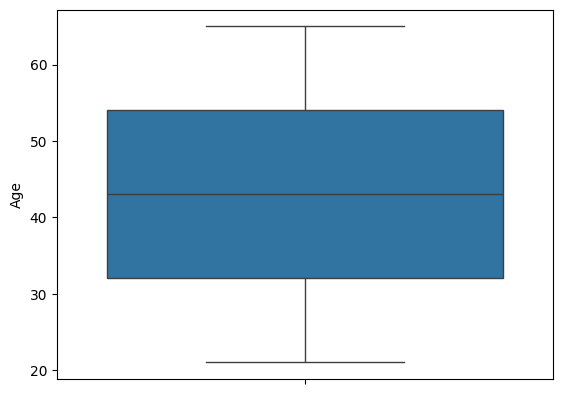

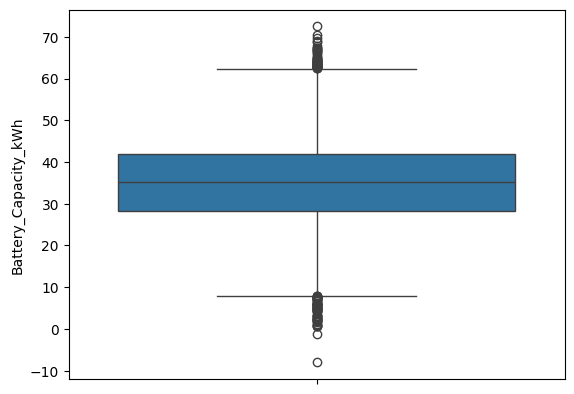

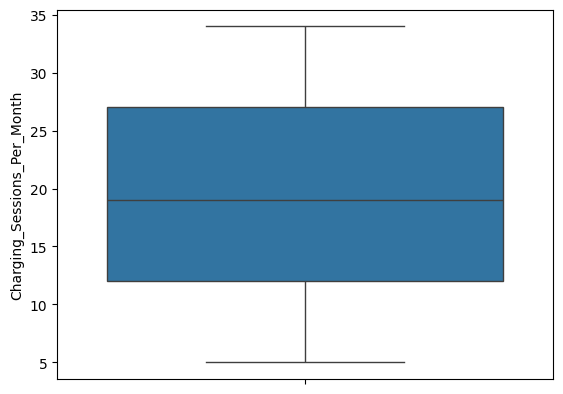

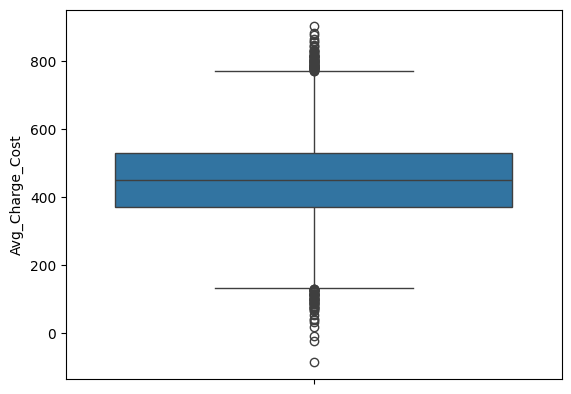

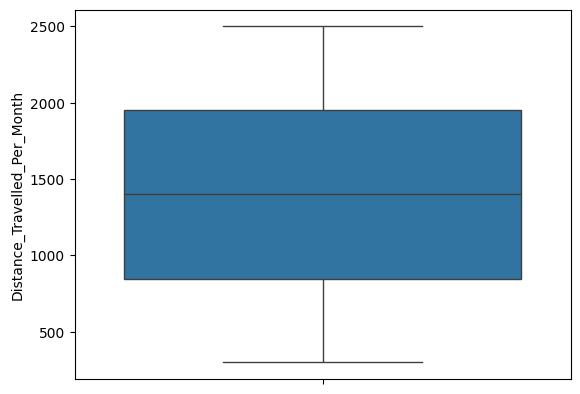

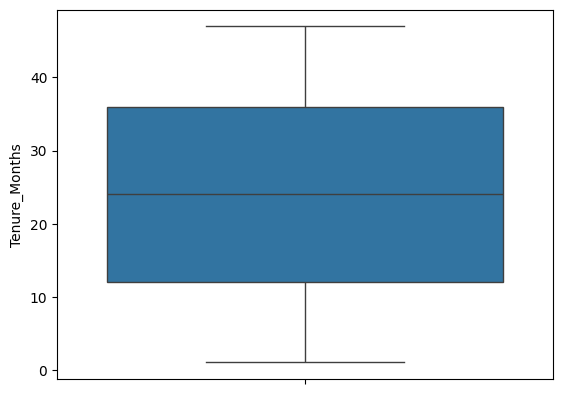

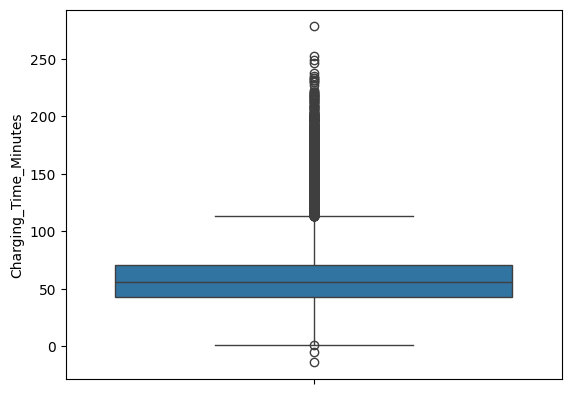

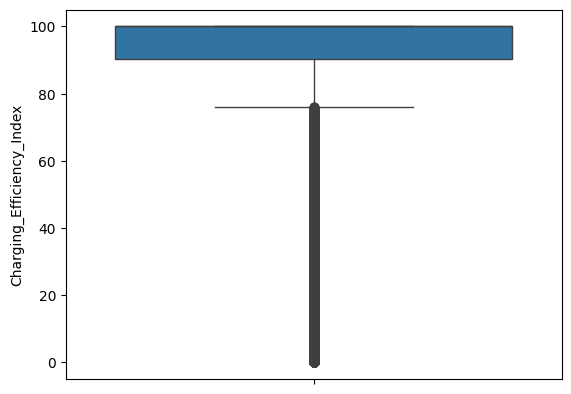

In [15]:
for i in ['Age', 'Battery_Capacity_kWh', 'Charging_Sessions_Per_Month', 'Avg_Charge_Cost','Distance_Travelled_Per_Month', 'Tenure_Months', 'Charging_Time_Minutes', 'Charging_Efficiency_Index']:
    sns.boxplot(df[i])
    plt.show()

- ['Battery_Capacity_kWh', 'Avg_Charge_Cost','Charging_Time_Minutes', 'Charging_Efficiency_Index'] have outliers and needs to be handled

In [16]:
num_cols = ['Age', 'Battery_Capacity_kWh', 'Charging_Sessions_Per_Month', 'Avg_Charge_Cost','Distance_Travelled_Per_Month', 'Tenure_Months', 'Charging_Time_Minutes', 'Charging_Efficiency_Index']
for i in num_cols:
    print(i,'Skewness', df[i].skew().round(3))

Age Skewness 0.017
Battery_Capacity_kWh Skewness -0.038
Charging_Sessions_Per_Month Skewness 0.012
Avg_Charge_Cost Skewness 0.011
Distance_Travelled_Per_Month Skewness -0.004
Tenure_Months Skewness -0.009
Charging_Time_Minutes Skewness 1.821
Charging_Efficiency_Index Skewness -2.192


- Charging_Time_Minutes Skewness 1.821, Charging_Efficiency_Index Skewness -2.192 needs transformation

In [17]:
df['Charging_Time_Minutes'] = np.log1p(df['Charging_Time_Minutes'])
df['Charging_Efficiency_Index'] = np.log1p(df['Charging_Efficiency_Index']+1) # since the values start from zero and gives null values
for i in num_cols:
    print(i,'Skewness', df[i].skew().round(3))

Age Skewness 0.017
Battery_Capacity_kWh Skewness -0.038
Charging_Sessions_Per_Month Skewness 0.012
Avg_Charge_Cost Skewness 0.011
Distance_Travelled_Per_Month Skewness -0.004
Tenure_Months Skewness -0.009
Charging_Time_Minutes Skewness -0.039
Charging_Efficiency_Index Skewness -3.945


- 'Charging_Efficiency_Index' has skewness and is prone to errors in the distributions

In [18]:
df.head(3)

,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,Charging_Efficiency_Index,High_Default_Risk
0,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,4.085976,4.624973,0
1,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,3.871201,4.588634,0
2,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,3.998201,4.624973,1


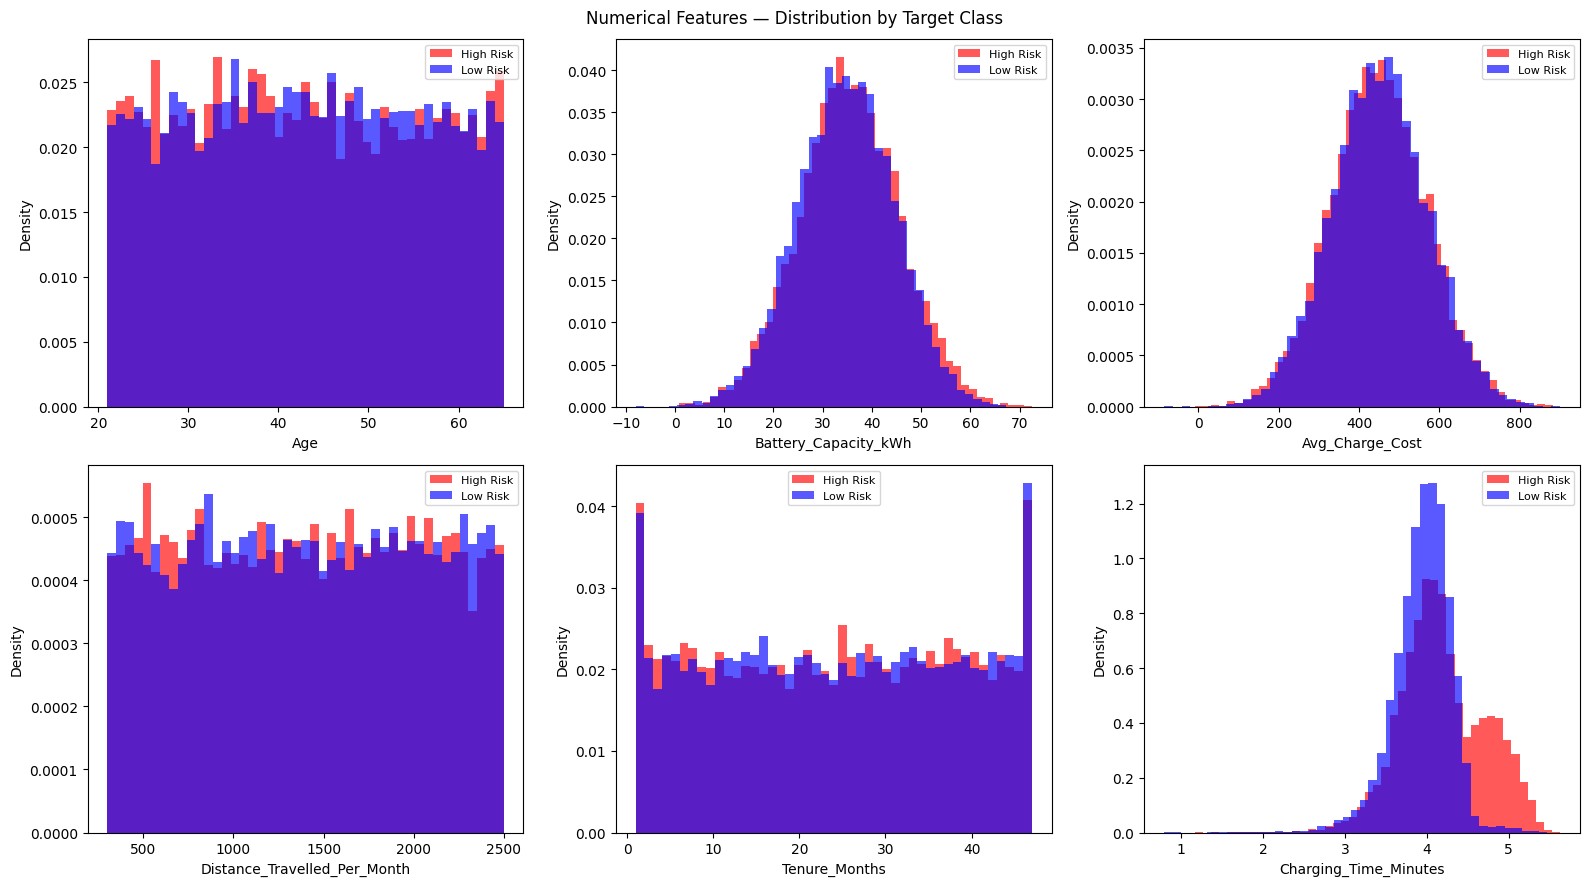

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Numerical Features — Distribution by Target Class")
axes = axes.flatten()
for i, col in enumerate(['Age', 'Battery_Capacity_kWh', 'Avg_Charge_Cost', 'Distance_Travelled_Per_Month', 'Tenure_Months', 'Charging_Time_Minutes']):
    yes_v = df.loc[df["High_Default_Risk"] == 1, col]
    no_v  = df.loc[df["High_Default_Risk"] == 0,  col]
    axes[i].hist(yes_v, bins=45, alpha=0.65, color='red',label="High Risk", density=True)
    axes[i].hist(no_v,  bins=45, alpha=0.65, color='blue', label="Low Risk",  density=True)
    axes[i].set_xlabel(col); axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

#### Feature Engineering

In [28]:
y = df['High_Default_Risk']
X = df.drop(columns = ['High_Default_Risk'], axis = 1)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18946 entries, 0 to 18945
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           18946 non-null  int64  
 1   City_Tier                     18946 non-null  object 
 2   EV_Type                       18946 non-null  object 
 3   Battery_Capacity_kWh          18946 non-null  float64
 4   Charging_Sessions_Per_Month   18946 non-null  int64  
 5   Avg_Charge_Cost               18946 non-null  float64
 6   Distance_Travelled_Per_Month  18946 non-null  int64  
 7   Income_Level                  18946 non-null  object 
 8   Loan_Taken                    18946 non-null  int64  
 9   Missed_Payments_Last_6M       18946 non-null  int64  
 10  Tenure_Months                 18946 non-null  int64  
 11  Charging_Location_Type        18946 non-null  object 
 12  App_Usage_Score               18946 non-null  int64  
 13  C

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
num_cols = ['Age', 'Battery_Capacity_kWh', 'Avg_Charge_Cost', 'Distance_Travelled_Per_Month', 'Tenure_Months', 'Charging_Time_Minutes', 'Charging_Efficiency_Index']
cat_cols = [i for i in X.columns if i not in num_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('Scaling',  RobustScaler(),  num_cols),
        ('Encoding', TargetEncoder(), cat_cols),
    ]
)

X_train_trans = preprocessor.fit_transform(X_train, y_train)
X_train_trans = pd.DataFrame(X_train_trans, columns=X_train.columns)

X_test_trans = preprocessor.transform(X_test)
X_test_trans = pd.DataFrame(X_test_trans, columns=X_train.columns)

In [23]:
X_train_trans['Avg_Charge_Cost'] = X_train_trans['Avg_Charge_Cost'].fillna(X_train_trans['Avg_Charge_Cost'].mean())
X_train_trans.head()

,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,Charging_Efficiency_Index
0,-0.409091,-0.903704,-0.017401,-0.216167,-0.875000,-1.182548,0.000000,0.448930,0.437433,0.263369,0.653118,0.643165,0.619345,0.462499,0.298685,0.365981
1,0.590909,1.088889,-0.918127,-0.770209,0.458333,0.680201,0.000000,0.449965,0.451730,0.593477,0.335527,0.647245,0.612143,0.462954,0.297835,0.368194
2,0.500000,-0.703704,0.114046,-0.255223,0.125000,-0.594080,0.000000,0.440052,0.444352,0.594264,0.655428,0.641030,0.268849,0.418963,0.630596,0.366047
3,0.272727,-0.185185,-1.931084,-0.595822,0.750000,1.413991,-14.162591,0.453977,0.445541,0.315076,0.650898,0.301922,0.268564,0.462954,0.649245,0.879629
4,0.590909,-0.866667,0.713696,-0.625795,-0.541667,-0.839785,0.000000,0.449965,0.445541,0.600121,0.650898,0.301922,0.612143,0.441462,0.315622,0.368194


#### Hyper Paramenters

In [24]:
models = {
    "Decision Tree"     : DecisionTreeClassifier(),
    "Random Forest"     : RandomForestClassifier(n_jobs=-1),
}

pipelines = {
    name: pl([
        ('clf',   model)
    ])
    for name, model in models.items()
}

In [25]:
param_grids = {
    "Decision Tree": {
        "clf__max_depth"        : [5, 10, 15, None],
        "clf__min_samples_leaf" : [1, 5, 10],
        "clf__criterion"        : ["gini", "entropy"],
    },
    "Random Forest": {
        "clf__n_estimators"     : [100, 200],
        "clf__max_depth"        : [10, 20, None],
        "clf__min_samples_leaf" : [1, 5],
    },
}


In [26]:
tuned_models  = {}
tuned_results = {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, pipeline in pipelines.items():
    print(f"\n  Tuning: {name}", flush=True)

    r_search = RandomizedSearchCV(
        estimator  = pipeline,
        param_distributions = param_grids[name],
        cv         = cv,
        scoring    = "roc_auc",
        n_jobs     = 1,
        verbose    = 1
    )
    r_search.fit(X_train_trans, y_train)

    tuned_models[name]  = r_search.best_estimator_
    tuned_results[name] = {
        "best_params" : r_search.best_params_,
        "best_cv_auc" : r_search.best_score_,
    }
    print(f"    Best params : {r_search.best_params_}")
    print(f"    Best CV AUC : {r_search.best_score_:.4f}")


  Tuning: Decision Tree
Fitting 3 folds for each of 10 candidates, totalling 30 fits
    Best params : {'clf__min_samples_leaf': 10, 'clf__max_depth': 10, 'clf__criterion': 'entropy'}
    Best CV AUC : 0.9977

  Tuning: Random Forest
Fitting 3 folds for each of 10 candidates, totalling 30 fits
    Best params : {'clf__n_estimators': 200, 'clf__min_samples_leaf': 1, 'clf__max_depth': 10}
    Best CV AUC : 1.0000



Decision Tree  Best threshold: 0.58
   Best F1       : 0.9964
   Precision     : 0.9982
   Recall        : 0.9947

Random Forest  Best threshold: 0.53
   Best F1       : 0.9988
   Precision     : 0.9994
   Recall        : 0.9982


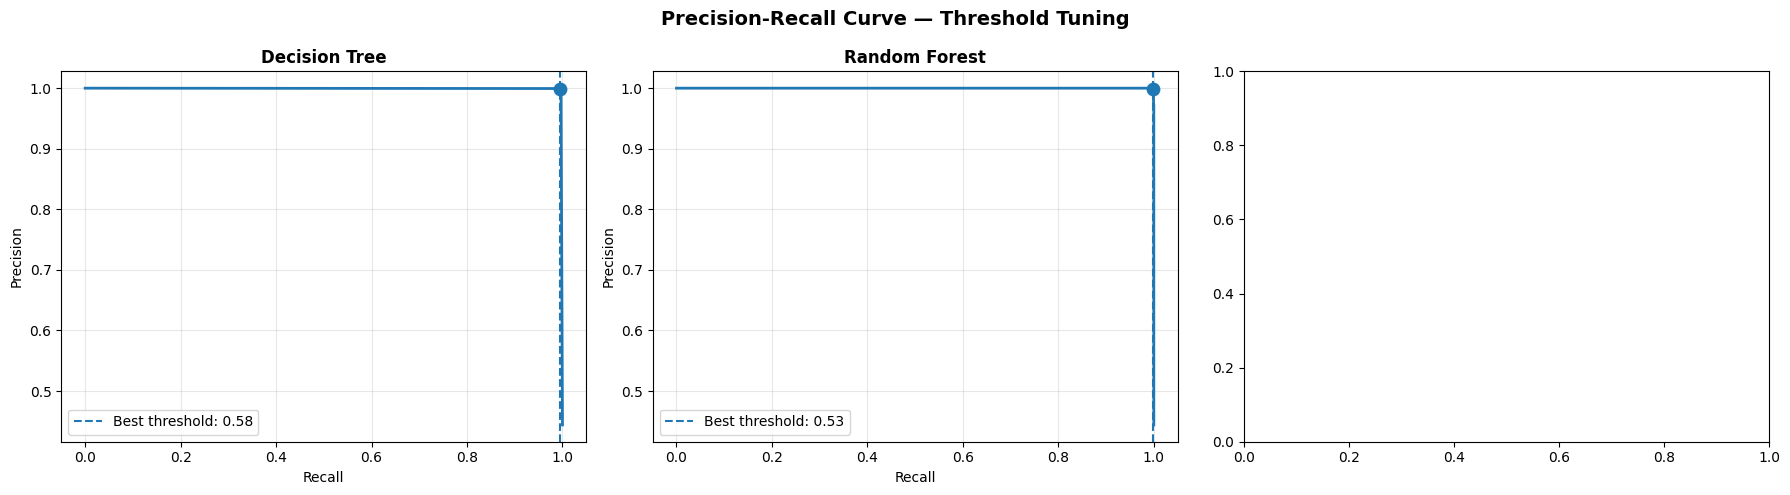

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Precision-Recall Curve — Threshold Tuning", fontsize=14, fontweight="bold")

best_thresholds = {}

for i, (name, pipeline) in enumerate(tuned_models.items()):
    y_prob = pipeline.predict_proba(X_test_trans)[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

    # Find threshold with best F1
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx  = f1_scores.argmax()
    best_thresh = thresholds[best_idx]
    best_thresholds[name] = best_thresh

    axes[i].plot(recalls, precisions, linewidth=2)
    axes[i].axvline(recalls[best_idx], linestyle='--', label=f"Best threshold: {best_thresh:.2f}")
    axes[i].scatter(recalls[best_idx], precisions[best_idx], zorder=5, s=80)
    axes[i].set_title(f"{name}", fontweight="bold")
    axes[i].set_xlabel("Recall")
    axes[i].set_ylabel("Precision")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

    print(f"\n{name}  Best threshold: {best_thresh:.2f}")
    print(f"   Best F1       : {f1_scores[best_idx]:.4f}")
    print(f"   Precision     : {precisions[best_idx]:.4f}")
    print(f"   Recall        : {recalls[best_idx]:.4f}")

plt.tight_layout()
plt.show()

#### Model Training

In [30]:
print("\n--- Results After Threshold Tuning ---")

for name, pipeline in tuned_models.items():
    y_prob      = pipeline.predict_proba(X_test_trans)[:, 1]
    best_thresh = best_thresholds[name]

    # Apply custom threshold instead of default 0.5
    y_pred_tuned = (y_prob >= best_thresh).astype(int)

    print(f"\n{'='*55}")
    print(f"  {name}  (threshold = {best_thresh:.2f})")
    print(f"{'='*55}")
    print(f"  F1        : {f1_score(y_test, y_pred_tuned):.4f}")
    print(f"  Recall    : {recall_score(y_test, y_pred_tuned):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred_tuned):.4f}")
    print(classification_report(y_test, y_pred_tuned))


--- Results After Threshold Tuning ---

  Decision Tree  (threshold = 0.58)
  F1        : 0.9964
  Recall    : 0.9947
  Precision : 0.9982
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2107
           1       1.00      0.99      1.00      1683

    accuracy                           1.00      3790
   macro avg       1.00      1.00      1.00      3790
weighted avg       1.00      1.00      1.00      3790


  Random Forest  (threshold = 0.53)
  F1        : 0.9988
  Recall    : 0.9982
  Precision : 0.9994
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2107
           1       1.00      1.00      1.00      1683

    accuracy                           1.00      3790
   macro avg       1.00      1.00      1.00      3790
weighted avg       1.00      1.00      1.00      3790



In [31]:
best_name     = "Decision Tree"
best_pipeline = tuned_models[best_name]
best_thresh   = best_thresholds[best_name]

y_prob       = best_pipeline.predict_proba(X_test_trans)[:, 1]
y_pred_final = (y_prob >= best_thresh).astype(int)

print(f"Best Model    : {best_name}")
print(f"Threshold     : {best_thresh:.2f}")
print(f"F1            : {f1_score(y_test, y_pred_final):.4f}")
print(f"Recall        : {recall_score(y_test, y_pred_final):.4f}")
print(f"Precision     : {precision_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC        : {average_precision_score(y_test, y_prob):.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_final))

Best Model    : Decision Tree
Threshold     : 0.58
F1            : 0.9964
Recall        : 0.9947
Precision     : 0.9982
ROC-AUC       : 0.9982
PR-AUC        : 0.9977

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2107
           1       1.00      0.99      1.00      1683

    accuracy                           1.00      3790
   macro avg       1.00      1.00      1.00      3790
weighted avg       1.00      1.00      1.00      3790



In [34]:
with open('best_model.pkl', 'wb') as f:
    pickle.dump({
        'model'     : best_pipeline,
        'threshold' : best_thresh,
        'name'      : best_name,
        'preprocessor' : preprocessor,
    }, f)

print("Model saved to best_model.pkl")

Model saved to best_model.pkl


In [35]:
X_train_trans.columns

Index(['Age', 'City_Tier', 'EV_Type', 'Battery_Capacity_kWh',
       'Charging_Sessions_Per_Month', 'Avg_Charge_Cost',
       'Distance_Travelled_Per_Month', 'Income_Level', 'Loan_Taken',
       'Missed_Payments_Last_6M', 'Tenure_Months', 'Charging_Location_Type',
       'App_Usage_Score', 'Charger_Working_Status', 'Charging_Time_Minutes',
       'Charging_Efficiency_Index'],
      dtype='object')